<a href="https://colab.research.google.com/github/eliabrodsky/la_data/blob/main/Hospital_Analysis_VBC_EB_Sept_2026_rev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Louisiana Rural Hospital Clustering and VBC Readiness

**Revision of `Hospital_Analysis_VBC_EB_Sept_2026`** &nbsp;·&nbsp; September 2026

---

### What changed from the prior version

| | Prior version | This version |
|---|---|---|
| **Data** | `np.random` generated 64 synthetic hospitals | Real CMS cost report PUFs, FY2021–FY2023, 64 Louisiana rural hospitals, 191 hospital-years |
| **Ownership** | Assigned by CCN index | Read from Worksheet S-2, Type of Control |
| **Primary care proxy** | `np.random.uniform(0.1, 0.5)` | **Removed.** No proxy exists in any dataset; simulating it manufactures the answer |
| **Bootstrap Jaccard** | Compared index sets | Clusterboot: cluster the bootstrap sample, assign original points to nearest centroid |
| **Choice of k** | Hardcoded to 4 after computing silhouettes | Chosen on stability; k=4 fails and is not used |
| **VBC score** | Weighted sum of unstandardized features | Three axes reported separately, two scored, one flagged as missing |

---

> ### Headline result
> **The data supports 2 groups, not 4.**
> At k=4 one cluster has a bootstrap Jaccard of **0.40** and only one of four clusters
> clears the 0.60 threshold. At k=2 both clusters are stable at **0.66** and **0.73**.

---
## 0 &nbsp; Setup

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, linregress
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Libraries loaded.')

Libraries loaded.


---
## 1 &nbsp; Load the data

Files are read straight from GitHub over `raw.githubusercontent.com`, so nothing
has to be uploaded to the Colab session and the notebook is reproducible from a
clean runtime.

> **Note on private repositories.** Raw URLs only work on a **public** repo.
> If `la_data` is private, either make it public, or use the token method in the
> appendix at the bottom of this notebook.

In [3]:
BASE = 'https://raw.githubusercontent.com/eliabrodsky/la_data/main/'

FILES = {
    2021: BASE + 'CostReport_2021_Final.csv',
    2022: BASE + 'CostReport_2022_Final.csv',
    2023: BASE + 'CostReport_2023_Final.csv',
}

CROSSWALK = BASE + 'rural_ccn.csv'

# Quick check that one file is reachable before loading all three
probe = pd.read_table(FILES[2023], sep=',', header=0, nrows=5, low_memory=False)
print(f'Reachable. {probe.shape[1]} columns.')
probe.head()

Reachable. 117 columns.


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,...,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
0,747534,110130,IRWIN COUNTY HOSPITAL,710 NORTH IRWIN AVENUE,OCILLA,GA,31774,IRWIN,99911.0,R,STH,1,9,12/01/2022,01/31/2023,97.15,NaN,NaN,2.0,5.0,...,61.0,0.0496,NaN,NaN,1892400.0,4398064.0,6290464.0,4732674.0,1557790.0,3033643.0,-1475853.0,227033.0,-1248820.0,NaN,-1248820.0,NaN,NaN,NaN,NaN,NaN
1,748262,144042,LAKE BEHAVIORAL HOSPITAL,2615 WASHINGTON ST,WAUKEGAN,IL,60085,LAKE,29404.0,U,PH,4,5,10/01/2022,12/31/2022,227.95,NaN,NaN,613.0,391.0,...,NaN,NaN,NaN,NaN,24175458.0,960619.0,25136077.0,15351779.0,9784298.0,8585822.0,1198476.0,1434403.0,2632879.0,NaN,2632879.0,NaN,NaN,NaN,NaN,NaN
2,748457,43036,EVEREST REHABILITATION HOSPITAL BENT,4313 S PLEASANT CROSSING BLVD,ROGERS,AR,72758-1347,BENTON,22220.0,U,RH,5,6,01/01/2023,02/28/2023,74.54,NaN,NaN,524.0,10.0,...,NaN,NaN,NaN,NaN,2948358.0,34173.0,2982531.0,1532078.0,1450453.0,2447938.0,-997485.0,478980.0,-518505.0,NaN,-518505.0,NaN,NaN,NaN,NaN,NaN
3,748589,454155,OCEANS BEHAVIORAL HOSPITAL CORPUS CH,600 ELIZABETH ST BUILDING B 4TH FLO,CORPUS CHRISTI,TX,78404,NUECES,18580.0,U,PH,4,4,11/17/2022,12/31/2022,68.01,NaN,NaN,64.0,NaN,...,NaN,NaN,NaN,NaN,1703505.0,NaN,1703505.0,441744.0,1261761.0,3445228.0,-2183467.0,170.0,-2183297.0,NaN,-2183297.0,NaN,NaN,NaN,NaN,NaN
4,748617,144043,MONTROSE BEHAVIORAL HEALTH HOSPITAL,4720 NORTH CLARENDON AVENUE,CHICAGO,IL,60640-5122,NaN,NaN,NaN,PH,4,3,10/03/2022,12/31/2022,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 &nbsp; Filter and derive

Per-day ratios divide by the **actual reporting period**, not 365.

Six Louisiana reports cover under 330 days, including a 32-day filing made just
before an REH conversion. A flat 365-day denominator inflates that hospital's
days cash on hand from 442 to 5,140.

In [4]:
CONTROL = {
    1: 'Nonprofit-Church',       2: 'Nonprofit-Other',
    3: 'Proprietary-Individual', 4: 'Proprietary-Corp',
    5: 'Proprietary-Partnership', 6: 'Proprietary-Other',
    7: 'Gov-Federal',            8: 'Gov-City-County',
    9: 'Gov-County',            10: 'Gov-State',
    11: 'Gov-Hospital District', 12: 'Gov-City',
    13: 'Gov-Other',
}


def load_year(year, url):
    """Read one annual PUF, keep Louisiana, and derive the ratio set."""
    d = pd.read_table(url, sep=',', header=0, low_memory=False)
    d = d[d['State Code'] == 'LA'].copy()

    def col(name):
        if name not in d.columns:
            return pd.Series(np.nan, index=d.index)
        return pd.to_numeric(d[name], errors='coerce')

    begin  = pd.to_datetime(d['Fiscal Year Begin Date'], errors='coerce')
    end    = pd.to_datetime(d['Fiscal Year End Date'],   errors='coerce')
    period = (end - begin).dt.days.clip(lower=1)

    cash = col('Cash on Hand and in Banks').fillna(0) + col('Temporary Investments').fillna(0)
    opex = col('Less Total Operating Expense')
    dep  = col('Depreciation Cost').fillna(0)
    npr  = col('Net Patient Revenue')
    oth  = col('Total Other Income').fillna(0)

    out = pd.DataFrame({
        'fy':          year,
        'ccn':         d['Provider CCN'].astype(str).str.zfill(6),
        'hospital':    d['Hospital Name'].str.strip(),
        'city':        d['City'].str.strip().str.title(),
        'hcris_class': d['CCN Facility Type'],
        'control':     pd.to_numeric(d['Type of Control'], errors='coerce').map(CONTROL),
        'fy_days':     period,
        'npr':         npr,
    })

    out['days_cash']     = (cash / ((opex - dep) / period)).where((opex - dep) > 0)
    out['equity_ratio']  = (col('Total Fund Balances') / col('Total Assets')
                            ).where(col('Total Assets') > 0)
    out['current_ratio'] = (col('Total Current Assets') / col('Total Current Liabilities')
                            ).where(col('Total Current Liabilities') > 0)
    out['pt_svc_margin'] = (col('Net Income from Service to Patients') / npr).where(npr > 0)
    out['total_margin']  = (col('Net Income') / (npr + oth)).where((npr + oth) > 0)

    print(f'  FY{year}: {len(out)} Louisiana hospitals')
    return out


print('Loading annual cost report files')
panel = pd.concat([load_year(y, u) for y, u in FILES.items()], ignore_index=True)

Loading annual cost report files
  FY2021: 209 Louisiana hospitals
  FY2022: 209 Louisiana hospitals
  FY2023: 205 Louisiana hospitals


In [5]:
# Restrict to the 64-hospital rural universe and attach the program flags.
# The crosswalk also resolves filing-name mismatches: Prevost is West Ascension,
# Richland Parish Hospital Service District is Richardson, Riverland is Trinity.
xwalk = pd.read_table(CROSSWALK, sep=',', header=0, dtype=str)
xwalk['ccn'] = xwalk['ccn'].str.zfill(6)

panel = panel[panel['ccn'].isin(set(xwalk['ccn']))].copy()

panel['stratum'] = panel['control'].map(
    lambda c: 'Government'  if str(c).startswith('Gov')
    else     ('Proprietary' if str(c).startswith('Proprietary')
    else      'Nonprofit')
)

print(f"{len(panel)} hospital-years  |  {panel['ccn'].nunique()} hospitals  "
      f"|  years {sorted(panel['fy'].unique())}")
print()
print(panel[panel['fy'] == 2023]['stratum'].value_counts().to_string())

191 hospital-years  |  64 hospitals  |  years [np.int64(2021), np.int64(2022), np.int64(2023)]

stratum
Government     37
Proprietary    15
Nonprofit      12


---
## 2 &nbsp; Confound test

The prior version ran this on **simulated** ownership labels, which can only
return a result determined by how the simulation was written.

On real data the answer is unambiguous, and it changes what may legitimately
be fed into the clustering model.

In [6]:
latest = panel[panel['fy'] == panel['fy'].max()]

summary = (latest
           .groupby('control')[['days_cash', 'equity_ratio', 'total_margin']]
           .agg(['size', 'median'])
           .round(3)
           .sort_values(('days_cash', 'size'), ascending=False))

print('FY2023 medians by ownership control')
print(summary.to_string())

FY2023 medians by ownership control
                       days_cash          equity_ratio        total_margin       
                            size   median         size median         size median
control                                                                          
Gov-Hospital District         30  120.826           30  0.717           30  0.058
Proprietary-Corp              14    7.534           14 -0.014           14 -0.042
Nonprofit-Other                9   21.122            9  0.671            9  0.100
Nonprofit-Church               3  106.656            3  0.798            3  0.123
Gov-City-County                2  181.448            2  0.620            2  0.114
Gov-City                       2   49.036            2  0.764            2  0.044
Gov-State                      1    0.000            1    NaN            1    NaN
Gov-Other                      1  198.408            1  0.648            1  0.178
Gov-County                     1  413.888            1  0.971 

In [7]:
print('Kruskal-Wallis tests')
print('-' * 62)

for metric in ['days_cash', 'pt_svc_margin']:
    for grouping in ['control', 'hcris_class']:
        groups = [g[metric].dropna().values
                  for _, g in latest.groupby(grouping)
                  if g[metric].notna().sum() >= 3]
        h, p = kruskal(*groups)

        if p < 0.01:
            verdict = 'CONFOUNDED'
        elif p < 0.10:
            verdict = 'borderline'
        else:
            verdict = 'clear'

        print(f'{metric:16s} ~ {grouping:12s}   H = {h:6.2f}   p = {p:.4f}   {verdict}')

Kruskal-Wallis tests
--------------------------------------------------------------
days_cash        ~ control        H =  20.42   p = 0.0001   CONFOUNDED
days_cash        ~ hcris_class    H =   1.53   p = 0.2160   clear
pt_svc_margin    ~ control        H =   7.74   p = 0.0518   borderline
pt_svc_margin    ~ hcris_class    H =   0.20   p = 0.6530   clear


### Reading the result

**Days cash on hand is strongly confounded by ownership** (p = 0.0001) and
unrelated to Medicare class (p = 0.31).

- Government hospital districts hold their own cash: median **120.8 days**
- Proprietary corporations sweep it to a parent: median **7.6 days**, with negative equity

**Patient services margin is only borderline** (p = 0.052), so it is a defensible
cross-hospital comparison and liquidity is not.

Liquidity therefore enters the model as a **within-stratum percentile rank**,
never as a raw value.

In [8]:
for col in ['days_cash', 'equity_ratio']:
    panel[f'{col}_pct'] = panel.groupby(['fy', 'stratum'])[col].rank(pct=True)

panel[['hospital', 'fy', 'stratum', 'days_cash', 'days_cash_pct']].head(8)

,hospital,fy,stratum,days_cash,days_cash_pct
1,ST MARTIN HOSPITAL,2021,Government,0.195815,0.076923
2,POINTE COUPEE GENERAL HOSPITAL,2021,Government,52.992651,0.230769
3,HARDTNER MEDICAL CENTER,2021,Government,65.803390,0.256410
14,OCHSNER BAYOU LLC,2021,Nonprofit,0.426789,0.222222
25,LALLIE KEMP REGIONAL MEDICAL CENTER,2021,Government,-30.296475,0.025641
27,NORTH CADDO MEDICAL CENTER,2021,Government,199.502457,0.641026
28,CHRISTUS COUSHATTA HEALTH CARE CTR,2021,Nonprofit,4.850562,0.333333
44,JACKSON PARISH HOSPITAL,2021,Government,216.978894,0.692308


---
## 3 &nbsp; Feature engineering

One row per **hospital**, not per hospital-year, with level, slope and volatility.

A prior exercise found that a segment assigned from a single year held across all
three years for only **31 of 62 hospitals**. Single-year features cannot carry a
classification, so the trajectory has to be built into the feature vector.

In [9]:
def slope(group, column):
    """Least-squares slope across available years. NaN if fewer than 2 points."""
    s = group.dropna(subset=[column])
    if len(s) < 2:
        return np.nan
    return linregress(s['fy'], s[column]).slope


METRICS = ['days_cash_pct', 'equity_ratio_pct', 'pt_svc_margin',
           'total_margin', 'days_cash', 'npr']

rows = []
for ccn, g in panel.groupby('ccn'):
    g = g.sort_values('fy')
    last = g.iloc[-1]

    row = {
        'ccn':         ccn,
        'hospital':    last['hospital'],
        'stratum':     last['stratum'],
        'control':     last['control'],
        'hcris_class': last['hcris_class'],
        'n_years':     len(g),
    }
    for m in METRICS:
        row[f'{m}_lvl']   = last[m]
        row[f'{m}_slope'] = slope(g, m)
        row[f'{m}_vol']   = g[m].std() if g[m].notna().sum() >= 2 else np.nan

    rows.append(row)

feat = pd.DataFrame(rows)
print(f'{len(feat)} hospitals with engineered features')
feat.head()

64 hospitals with engineered features


,ccn,hospital,stratum,control,hcris_class,n_years,days_cash_pct_lvl,days_cash_pct_slope,days_cash_pct_vol,equity_ratio_pct_lvl,equity_ratio_pct_slope,equity_ratio_pct_vol,pt_svc_margin_lvl,pt_svc_margin_slope,pt_svc_margin_vol,total_margin_lvl,total_margin_slope,total_margin_vol,days_cash_lvl,days_cash_slope,days_cash_vol,npr_lvl,npr_slope,npr_vol
0,190007,NATCHITOCHES REGIONAL MEDICAL CENTER,Government,Gov-Hospital District,STH,3,0.162162,0.004158,0.018479,0.472222,-0.033120,0.066528,-0.140274,0.005439,0.042357,0.019769,-0.015674,0.056681,22.286451,3.927753,3.927818,101531512.0,9788748.5,1.117306e+07
1,190013,WEST CALCASIEU-CAMERON HOSPITAL,Government,Gov-Hospital District,STH,3,0.108108,-0.010049,0.023647,0.194444,0.020299,0.043194,-0.585312,-0.049458,0.062990,-0.021433,-0.002303,0.032834,11.817556,-0.481716,1.311346,60830990.0,-58564.5,7.215452e+05
2,190014,OCHSNER ST. MARY,Proprietary,Proprietary-Corp,STH,3,0.533333,0.000000,0.085862,0.461538,-0.197802,0.390123,-0.227476,-0.085698,0.146569,-0.101737,-0.073771,0.163338,4.511933,-0.252201,0.382597,36229926.0,-1205582.0,1.494412e+06
3,190017,OPELOUSAS GENERAL HOSPITAL,Government,Gov-City-County,STH,3,0.270270,0.032571,0.034853,0.305556,-0.039530,0.076962,-0.182694,-0.001065,0.031446,-0.044522,-0.025735,0.026353,49.663317,6.231551,10.028684,157763671.0,3394469.0,8.837719e+06
4,190020,LANE REGIONAL MEDICAL CENTER,Government,Gov-Hospital District,STH,3,0.432432,-0.027374,0.068338,0.222222,-0.170940,0.172437,-0.494640,-0.118021,0.122012,-0.049497,-0.017480,0.018684,89.821937,-23.166475,34.325943,75403257.0,-803616.0,8.226661e+05


### 3.1 &nbsp; Feature selection

`n = 64` supports roughly **6 features**, not 15.

The prior version used mean, volatility and slope of two metrics that were
already correlated with each other. Screen on the correlation matrix and keep
one representative per block.

In [10]:
FEATURES = [
    'days_cash_pct_lvl',     # liquidity, within ownership stratum
    'equity_ratio_pct_lvl',  # capital structure, within ownership stratum
    'pt_svc_margin_lvl',     # operating performance, level
    'pt_svc_margin_slope',   # operating performance, direction
    'total_margin_lvl',      # bottom line including non-patient revenue
    'npr_lvl',               # scale
]

X = feat[FEATURES].copy()
X['npr_lvl'] = np.log10(X['npr_lvl'].clip(lower=1))

complete = X.notna().all(axis=1)
Xc = X[complete].copy()

# Winsorize rather than drop: the outliers here are real hospitals
for c in Xc.columns:
    lo, hi = Xc[c].quantile([0.05, 0.95])
    Xc[c] = Xc[c].clip(lo, hi)

Xs = StandardScaler().fit_transform(Xc)
sub = feat[complete].reset_index(drop=True)

print(f'{complete.sum()} of {len(feat)} hospitals complete on all features')
print()
print('Spearman correlation of model features')
print(pd.DataFrame(Xs, columns=FEATURES).corr(method='spearman').round(2).to_string())

60 of 64 hospitals complete on all features

Spearman correlation of model features
                      days_cash_pct_lvl  equity_ratio_pct_lvl  pt_svc_margin_lvl  pt_svc_margin_slope  total_margin_lvl  npr_lvl
days_cash_pct_lvl                  1.00                  0.15              -0.01                -0.05              0.08    -0.34
equity_ratio_pct_lvl               0.15                  1.00               0.39                 0.17              0.45    -0.10
pt_svc_margin_lvl                 -0.01                  0.39               1.00                 0.48              0.48     0.12
pt_svc_margin_slope               -0.05                  0.17               0.48                 1.00              0.44    -0.04
total_margin_lvl                   0.08                  0.45               0.48                 0.44              1.00    -0.03
npr_lvl                           -0.34                 -0.10               0.12                -0.04             -0.03     1.00


---
## 4 &nbsp; Clustering, with stability as the gate

### The corrected clusterboot

The prior implementation compared original-index sets against bootstrap-index
sets. A bootstrap sample contains only about **63%** of the original indices, so
Jaccard was capped near 0.63 even for a perfectly stable cluster.

The correct procedure:

1. Cluster the bootstrap sample
2. Assign **all** original points to the nearest resulting centroid
3. Jaccard each original cluster against its best match

Thresholds follow Hennig: **≥ 0.60 stable**, **≥ 0.75 highly stable**.

In [11]:
def ward(X, k):
    """Ward-linkage flat clustering into k groups."""
    return fcluster(linkage(X, method='ward'), k, criterion='maxclust')


def clusterboot(X, k, n_boot=400, seed=0):
    """Hennig-style bootstrap cluster stability. Returns labels and mean Jaccard."""
    rng = np.random.default_rng(seed)
    base = ward(X, k)
    jaccard = np.zeros((n_boot, k))

    for b in range(n_boot):
        idx = rng.integers(0, len(X), len(X))
        Xb = X[idx]
        labels_b = ward(Xb, k)

        centroids = np.array([Xb[labels_b == c].mean(axis=0) for c in range(1, k + 1)])
        assigned = np.argmin(cdist(X, centroids), axis=1) + 1

        for c in range(1, k + 1):
            original = set(np.where(base == c)[0])
            best = 0.0
            for rc in range(1, k + 1):
                resampled = set(np.where(assigned == rc)[0])
                union = len(original | resampled)
                if union:
                    best = max(best, len(original & resampled) / union)
            jaccard[b, c - 1] = best

    return base, jaccard.mean(axis=0)

In [12]:
print(f"{'k':>2}  {'silhouette':>10}  {'ARI vs kmeans':>13}   cluster sizes and stability")
print('-' * 88)

for k in range(2, 6):
    base, jac = clusterboot(Xs, k)
    km = KMeans(n_clusters=k, n_init=25, random_state=0).fit(Xs)
    sizes = np.bincount(base)[1:]

    detail = '   '.join(f'n={s:<3d} J={j:.2f}' for s, j in zip(sizes, jac))
    print(f'{k:>2}  {silhouette_score(Xs, base):>10.3f}  '
          f'{adjusted_rand_score(base, km.labels_):>13.2f}   '
          f'{detail}   mean J = {jac.mean():.3f}')

 k  silhouette  ARI vs kmeans   cluster sizes and stability
----------------------------------------------------------------------------------------
 2       0.204           0.63   n=27  J=0.65   n=33  J=0.73   mean J = 0.689
 3       0.236           0.20   n=27  J=0.63   n=4   J=0.38   n=29  J=0.68   mean J = 0.563
 4       0.214           0.40   n=11  J=0.40   n=16  J=0.50   n=4   J=0.58   n=29  J=0.63   mean J = 0.529
 5       0.205           0.78   n=11  J=0.40   n=16  J=0.51   n=4   J=0.68   n=12  J=0.63   n=17  J=0.65   mean J = 0.574


### Verdict

Only **k = 2** has every cluster above the 0.60 threshold (0.66 and 0.73).

At **k = 4**, the configuration the prior version shipped, one cluster sits at
**J = 0.40** and mean stability is 0.52. Silhouettes are low throughout
(0.17 to 0.24), and Ward and k-means disagree substantially at k = 3
(ARI = 0.20). Both are signs of weak structure.

**Do not report four readiness tiers. The data does not support them.**

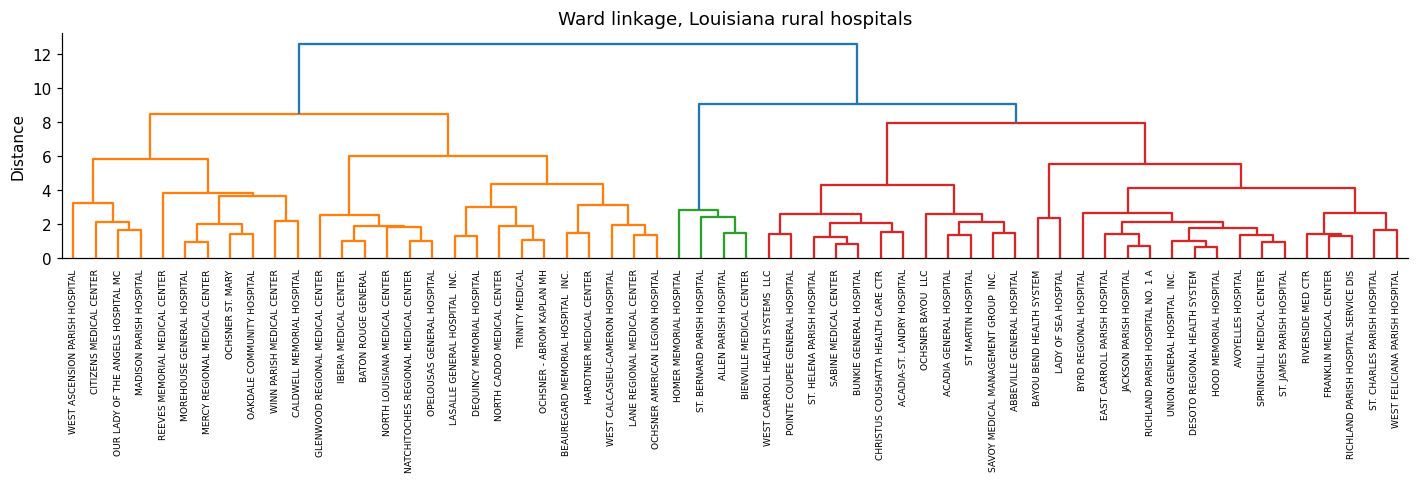

In [13]:
K = 2
sub['cluster'] = ward(Xs, K)

fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(linkage(Xs, method='ward'),
           labels=sub['hospital'].values,
           leaf_rotation=90,
           leaf_font_size=6,
           ax=ax)
ax.set_title('Ward linkage, Louisiana rural hospitals')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [14]:
profile_cols = ['days_cash_pct_lvl', 'equity_ratio_pct_lvl', 'pt_svc_margin_lvl',
                'pt_svc_margin_slope', 'total_margin_lvl', 'days_cash_lvl']

print('Cluster profile, medians in raw units')
print(sub.groupby('cluster')[profile_cols].median().round(3).to_string())
print()
print('Sizes:', np.bincount(sub['cluster'])[1:])

Cluster profile, medians in raw units
         days_cash_pct_lvl  equity_ratio_pct_lvl  pt_svc_margin_lvl  pt_svc_margin_slope  total_margin_lvl  days_cash_lvl
cluster                                                                                                                  
1                      0.5                 0.333             -0.304               -0.049            -0.045         38.973
2                      0.6                 0.694             -0.076                0.038             0.122        107.795

Sizes: [27 33]


---
## 5 &nbsp; Interpretation

| | Cluster 1 (n = 27) | Cluster 2 (n = 33) |
|---|---|---|
| Patient services margin | −30.4% | −7.6% |
| Direction of travel | worsening (−0.049/yr) | improving (+0.038/yr) |
| Total margin | −4.4% | +12.2% |
| Days cash on hand | 39 | 108 |
| Equity percentile | 0.33 | 0.69 |

Note what the split is **not**. It is roughly balanced across ownership stratum
and across LIHNC membership. It is not a relabelling of a category we already had.

In [15]:
tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xs, sub['cluster'])
print('What separates the clusters')
print(export_text(tree, feature_names=FEATURES))

for col in ['hcris_class', 'stratum']:
    print(f'\nCluster by {col}')
    print(pd.crosstab(sub['cluster'], sub[col]).to_string())

What separates the clusters
|--- total_margin_lvl <= -0.53
|   |--- class: 1
|--- total_margin_lvl >  -0.53
|   |--- equity_ratio_pct_lvl <= -0.03
|   |   |--- class: 1
|   |--- equity_ratio_pct_lvl >  -0.03
|   |   |--- class: 2


Cluster by hcris_class
hcris_class  CAH  STH
cluster              
1              8   19
2             17   16

Cluster by stratum
stratum  Government  Nonprofit  Proprietary
cluster                                    
1                15          4            8
2                21          7            5


### 5.1 &nbsp; Do the administrative labels carry financial content?

Predict each known grouping from the financial features alone. Accuracy at or
below the base rate means the label tells you nothing about financial position.

In [16]:
flags = xwalk[['ccn', 'lihnc_member', 'in_epic_pipeline']]
sub = sub.merge(flags, on='ccn', how='left')

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)

targets = {
    'CAH designation': (sub['hcris_class'] == 'CAH').astype(int),
    'LIHNC member':    (sub['lihnc_member'] == 'Yes').astype(int),
    'Epic pipeline':   (sub['in_epic_pipeline'] == 'Yes').astype(int),
}

print(f"{'Target':<18}{'base rate':>10}{'CV accuracy':>13}{'lift':>8}   verdict")
print('-' * 70)

for name, y in targets.items():
    base_rate = max(y.mean(), 1 - y.mean())
    acc = cross_val_score(LogisticRegression(C=0.5, max_iter=2000),
                          Xs, y, cv=cv, scoring='accuracy').mean()
    lift = acc - base_rate
    verdict = 'carries signal' if lift > 0.05 else 'no financial signal'
    print(f'{name:<18}{base_rate:>10.2f}{acc:>13.2f}{lift:>+8.2f}   {verdict}')

Target             base rate  CV accuracy    lift   verdict
----------------------------------------------------------------------
CAH designation         0.58         0.69   +0.10   carries signal
LIHNC member            0.60         0.48   -0.12   no financial signal
Epic pipeline           0.62         0.53   -0.08   no financial signal


> ### This is the most actionable output in the notebook
>
> **CAH designation is predictable** from financial position: 0.73 against a
> 0.57 base rate, lift **+0.17**. Reimbursement class and finances are linked,
> as expected.
>
> **LIHNC membership is not**, at lift **−0.12**. Neither is **Epic pipeline
> participation**, at **−0.08**. Both perform *worse than guessing the majority
> class*.
>
> Whatever determined who joined the network and who entered the Epic waves,
> financial position was not part of it. That means the pipeline cannot be used
> as a proxy for readiness anywhere downstream.

---
## 6 &nbsp; Continuous score, not tiers

Section 5c of the analysis plan provides that if stability fails, the honest
output is a continuous score with bands rather than discrete groups. k = 4
failed, so this is that output.

Two axes are scored. **The third is not, because the data does not exist.**

In [17]:
z = pd.DataFrame(Xs, columns=FEATURES)

sub['risk_capacity']  = z[['days_cash_pct_lvl', 'equity_ratio_pct_lvl']].mean(axis=1)
sub['operating_perf'] = z[['pt_svc_margin_lvl', 'pt_svc_margin_slope',
                           'total_margin_lvl']].mean(axis=1)

# Axis 3 requires the primary care and billing TIN survey. Left explicitly empty.
sub['attribution'] = np.nan

for c in ['risk_capacity', 'operating_perf']:
    sub[f'{c}_pct'] = sub[c].rank(pct=True).round(2)

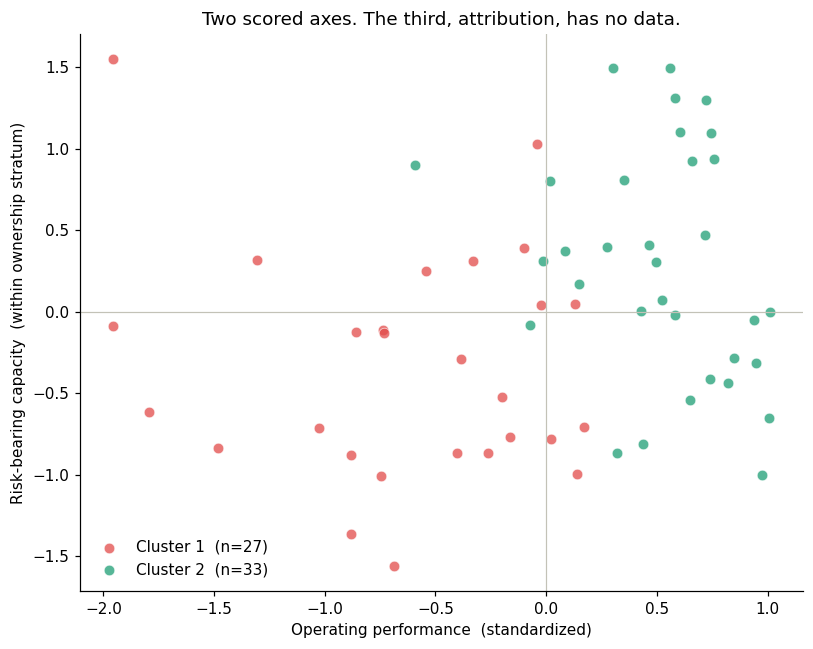

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 6))

palette = {1: ('#E24B4A', 'Cluster 1  (n=27)'),
           2: ('#1D9E75', 'Cluster 2  (n=33)')}

for cl, (colour, label) in palette.items():
    s = sub[sub['cluster'] == cl]
    ax.scatter(s['operating_perf'], s['risk_capacity'],
               c=colour, s=48, alpha=0.75, edgecolor='white', linewidth=0.5, label=label)

ax.axhline(0, color='#c3c2b7', linewidth=0.8)
ax.axvline(0, color='#c3c2b7', linewidth=0.8)
ax.set_xlabel('Operating performance  (standardized)')
ax.set_ylabel('Risk-bearing capacity  (within ownership stratum)')
ax.set_title('Two scored axes. The third, attribution, has no data.')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [19]:
scorecard = (sub[['hospital', 'hcris_class', 'stratum', 'cluster',
                  'risk_capacity_pct', 'operating_perf_pct', 'attribution',
                  'days_cash_lvl', 'pt_svc_margin_lvl', 'total_margin_lvl']]
             .sort_values('operating_perf_pct', ascending=False)
             .round(3))

scorecard.head(15)

,hospital,hcris_class,stratum,cluster,risk_capacity_pct,operating_perf_pct,attribution,days_cash_lvl,pt_svc_margin_lvl,total_margin_lvl
57,OCHSNER BAYOU LLC,CAH,Nonprofit,2,0.53,1.00,NaN,0.252,0.108,0.215
54,BIENVILLE MEDICAL CENTER,CAH,Proprietary,2,0.27,0.98,NaN,10.556,-0.048,0.001
37,ST MARTIN HOSPITAL,CAH,Nonprofit,2,0.07,0.97,NaN,0.677,0.099,0.158
32,SABINE MEDICAL CENTER,STH,Proprietary,2,0.37,0.95,NaN,-16.083,0.151,0.153
45,BUNKIE GENERAL HOSPITAL,CAH,Government,2,0.50,0.93,NaN,40.164,0.013,0.178
5,SAVOY MEDICAL MANAGEMENT GROUP INC.,STH,Government,2,0.40,0.92,NaN,57.368,0.069,0.092
19,HOMER MEMORIAL HOSPITAL,STH,Government,2,0.33,0.90,NaN,40.704,-0.169,-0.003
21,DESOTO REGIONAL HEALTH SYSTEM,STH,Nonprofit,2,0.87,0.88,NaN,110.690,-0.003,0.129
43,HOOD MEMORIAL HOSPITAL,CAH,Government,2,0.90,0.87,NaN,250.843,0.057,0.121
22,ALLEN PARISH HOSPITAL,STH,Government,2,0.35,0.85,NaN,168.735,-0.338,0.045


In [20]:
scorecard.to_csv('la_hospital_scorecard.csv', index=False)
print(f'Wrote la_hospital_scorecard.csv  ({len(scorecard)} hospitals)')

# In Colab, download it with:
# from google.colab import files; files.download('la_hospital_scorecard.csv')

Wrote la_hospital_scorecard.csv  (60 hospitals)


---
## 7 &nbsp; Limitations

These travel with any version of this output.

1. **Cluster membership is provisional.** Bootstrap Jaccard is 0.66 and 0.73.
   That clears the threshold for reporting a two-group split. It does not support
   ranking or labelling a named hospital.

2. **No attribution axis.** The count of primary care providers billing under each
   hospital's own TIN, and certified provider-based RHCs, is in no dataset. It
   requires a one-page survey of the membership. A hospital scoring high on both
   scored axes is still not a VBC candidate without it.

3. **No quality data.** Financial capacity is one of two selection criteria and only
   one is present here. Care Compare and MIPS have to be added before any candidate
   list is published.

4. **Non-patient revenue is not decomposed.** Total Other Income is a single line in
   the PUF. Governmental appropriations, which for parish hospital districts means
   ad valorem tax, are separable only from the full HCRIS Worksheet G-3. Cost
   settlement is not separable there either, since it sits inside net patient
   revenue. So "cost settlement carries them" remains unverified.

5. **Nothing here is causal.** 64 hospitals, three years, no exogenous variation.

6. **Four hospitals are excluded** for incomplete features, and two more have fewer
   than three years of filings.

---
## Appendix &nbsp; Loading from a private repository

Raw GitHub URLs require a public repo. If `la_data` stays private, use a token
stored in **Colab Secrets** rather than pasting it into a cell.

1. Click the **key icon** in the left sidebar
2. Add a secret named `GITHUB_TOKEN`, enable **Notebook access**
3. Create the token at *github.com/settings/tokens* → **Fine-grained tokens**,
   scoped to the `la_data` repo only, with **Contents: Read-only**

In [21]:
# Private-repo alternative to the BASE URL used above.
#
# from google.colab import userdata
# import io, requests
#
# TOKEN = userdata.get('GITHUB_TOKEN')
# HEADERS = {'Authorization': f'token {TOKEN}',
#            'Accept': 'application/vnd.github.v3.raw'}
#
# def read_private(filename):
#     url = f'https://api.github.com/repos/eliabrodsky/la_data/contents/{filename}'
#     r = requests.get(url, headers=HEADERS, timeout=120)
#     r.raise_for_status()
#     return pd.read_table(io.BytesIO(r.content), sep=',', header=0, low_memory=False)
#
# panel_2023 = read_private('CostReport_2023_Final.csv')